# ThreatLens AI — Notebook 02: Anomaly Detection (Isolation Forest)

**Stage in the pipeline:** `AI Engines → Anomaly Detection`
**Input:** `data/processed/cicids2017_cleaned.parquet` (produced by Notebook 01)

### What this notebook does
1. Loads the cleaned dataset from Notebook 01
2. Explains *why* Isolation Forest, and how unsupervised anomaly detection actually works
3. Selects safe model features (no label leakage)
4. Splits the data (for evaluation only — the model itself never sees labels while training)
5. Trains an Isolation Forest
6. Evaluates it against the real attack labels — precision, recall, F1, confusion matrix
7. Visualizes anomaly score distributions and which attack types get caught vs missed
8. Saves the trained model for reuse later (by the FastAPI service, eventually)

### Why Isolation Forest, specifically
Isolation Forest is **unsupervised** — it never needs to be told which rows are attacks. It works by randomly partitioning the data with decision trees; anomalies are the points that get "isolated" into their own tiny partition in very few splits, because they don't look like the bulk of normal traffic. This matches real-world security monitoring well: in production, most incoming traffic is *unlabeled*, and you often want to catch attack patterns you've never explicitly seen before — something a supervised classifier (Notebook 03) can't do on its own.


In [2]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

from src.models.anomaly import (
    select_feature_columns,
    train_isolation_forest,
    predict_anomalies,
    evaluate_anomaly_model,
    save_model,
)

sns.set_theme(style="darkgrid")
plt.rcParams["figure.figsize"] = (10, 5)

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
MODELS_DIR = PROJECT_ROOT / "models" / "anomaly"


## 1. Load the cleaned dataset

This is the exact file Notebook 01 produced — no reloading of raw CSVs, no re-cleaning. One clean source of truth for every notebook from here on.


In [3]:
df = pd.read_parquet(PROCESSED_DIR / "cicids2017_cleaned.parquet")
print(f"Loaded {df.shape[0]:,} rows, {df.shape[1]} columns")
df["attack_category"].value_counts()

Loaded 2,572,640 rows, 81 columns


attack_category
Normal           2146899
DDoS              321759
Port Scanning      90694
Brute Force         9150
Web Attack          2143
Botnet              1948
Infiltration          36
Other                 11
Name: count, dtype: int64

## 2. Select model features

We use every numeric traffic-behavior column (flow duration, packet counts, byte rates, etc.) and explicitly exclude anything that isn't a real behavioral signal — the raw `label`, the derived `attack_category`, and `source_file` (which day the row came from — a metadata artifact, not something an attacker's traffic pattern would ever "know" or be influenced by).

`select_feature_columns()` lives in `src/models/anomaly.py` rather than being retyped here, so Notebook 03's classifier will start from the exact same feature set — any performance difference between models will be a real difference in the algorithm, not an accidental difference in inputs.


In [4]:
feature_cols = select_feature_columns(df)
print(f"Using {len(feature_cols)} feature columns:")
print(feature_cols)

Using 78 feature columns:
['destination_port', 'flow_duration', 'total_fwd_packets', 'total_backward_packets', 'total_length_of_fwd_packets', 'total_length_of_bwd_packets', 'fwd_packet_length_max', 'fwd_packet_length_min', 'fwd_packet_length_mean', 'fwd_packet_length_std', 'bwd_packet_length_max', 'bwd_packet_length_min', 'bwd_packet_length_mean', 'bwd_packet_length_std', 'flow_bytes_s', 'flow_packets_s', 'flow_iat_mean', 'flow_iat_std', 'flow_iat_max', 'flow_iat_min', 'fwd_iat_total', 'fwd_iat_mean', 'fwd_iat_std', 'fwd_iat_max', 'fwd_iat_min', 'bwd_iat_total', 'bwd_iat_mean', 'bwd_iat_std', 'bwd_iat_max', 'bwd_iat_min', 'fwd_psh_flags', 'bwd_psh_flags', 'fwd_urg_flags', 'bwd_urg_flags', 'fwd_header_length', 'bwd_header_length', 'fwd_packets_s', 'bwd_packets_s', 'min_packet_length', 'max_packet_length', 'packet_length_mean', 'packet_length_std', 'packet_length_variance', 'fin_flag_count', 'syn_flag_count', 'rst_flag_count', 'psh_flag_count', 'ack_flag_count', 'urg_flag_count', 'cwe_fl

## 3. Train/test split

Isolation Forest doesn't use labels during training — but we still split the data so we can fairly *evaluate* it afterward on rows the split set aside, and so later notebooks (which do use labels) share the same split for a fair model-to-model comparison. `stratify=` keeps the same attack-category proportions in both sets.


In [5]:
X = df[feature_cols]
y_is_attack = (df["attack_category"] != "Normal").astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_is_attack, test_size=0.25, random_state=42, stratify=y_is_attack
)

print(f"Train: {X_train.shape[0]:,} rows | Test: {X_test.shape[0]:,} rows")
print(f"Attack ratio — train: {y_train.mean():.2%} | test: {y_test.mean():.2%}")

Train: 1,929,480 rows | Test: 643,160 rows
Attack ratio — train: 16.55% | test: 16.55%


## 4. Train the Isolation Forest

`contamination` tells the model roughly what fraction of the data to expect as anomalous — it's used to set the decision threshold on the raw anomaly scores. We estimate it directly from the **training** attack ratio above rather than picking an arbitrary number, since in this dataset we happen to know the true ratio (in a fully unlabeled production setting, this would instead come from a rough analyst estimate or be tuned operationally).

Note: the model is trained on `X_train` features only — `y_train` is never passed in.


In [6]:
estimated_contamination = float(y_train.mean())
print(f"Using contamination = {estimated_contamination:.3f}")

model = train_isolation_forest(X_train, contamination=estimated_contamination)
print("Model trained.")

Using contamination = 0.165
Model trained.


## 5. Evaluate against real attack labels

The model produces an anomaly flag per row *without ever having seen these labels*. Now — and only now — we compare its flags against the real `attack_category` labels, purely to measure how good the unsupervised signal actually is.

We report precision/recall/F1 rather than plain accuracy, because with imbalanced classes a model that just guesses "normal" for everything would still score a high, misleading accuracy.


In [7]:
pred = predict_anomalies(model, X_test)

results = evaluate_anomaly_model(y_test, pred["is_anomaly"])
print(f"\nPrecision: {results['precision']:.3f} | Recall: {results['recall']:.3f} | F1: {results['f1']:.3f}")

              precision    recall  f1-score   support

      Normal       0.90      0.90      0.90    536725
     Anomaly       0.48      0.49      0.49    106435

    accuracy                           0.83    643160
   macro avg       0.69      0.69      0.69    643160
weighted avg       0.83      0.83      0.83    643160


Precision: 0.485 | Recall: 0.486 | F1: 0.486


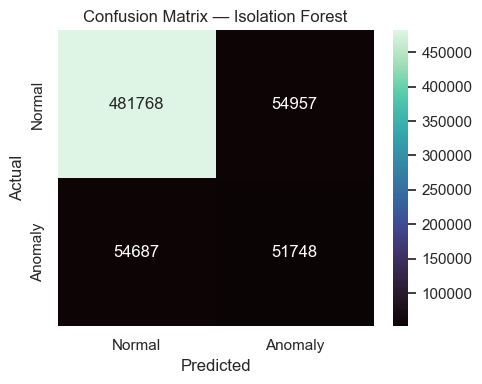

In [8]:
cm = results["confusion_matrix"]
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="mako",
            xticklabels=["Normal", "Anomaly"], yticklabels=["Normal", "Anomaly"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — Isolation Forest")
plt.tight_layout()
plt.show()

### Anomaly score distribution by true class

If the model is learning something real, normal traffic should cluster toward higher (less anomalous) scores, and actual attacks should skew lower. This plot is a sanity check independent of whatever threshold `contamination` happened to pick.


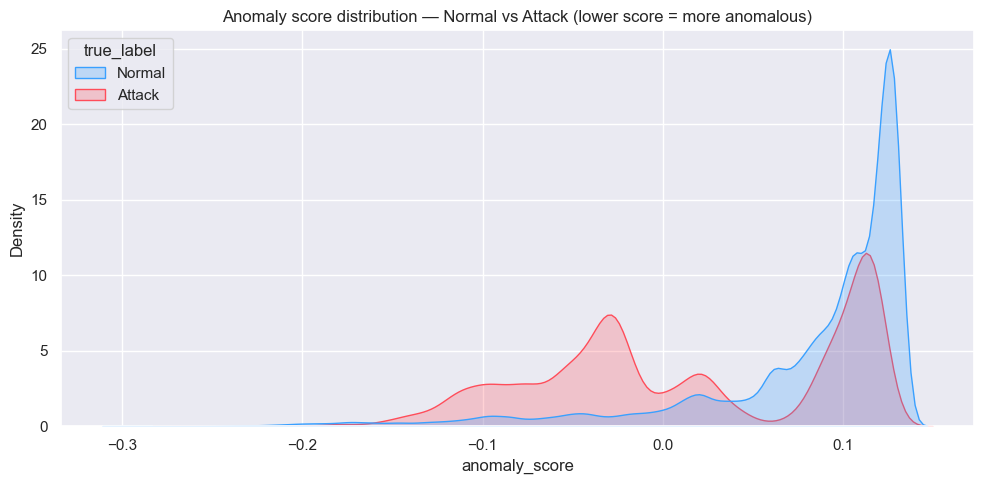

In [9]:
plot_df = X_test.copy()
plot_df["anomaly_score"] = pred["anomaly_score"].values
plot_df["true_label"] = y_test.map({0: "Normal", 1: "Attack"}).values

plt.figure(figsize=(10, 5))
sns.kdeplot(data=plot_df, x="anomaly_score", hue="true_label", fill=True, common_norm=False, palette=["#3aa0ff", "#ff4d5a"])
plt.title("Anomaly score distribution — Normal vs Attack (lower score = more anomalous)")
plt.tight_layout()
plt.show()

### Which attack types does the model catch vs miss?

Isolation Forest has no concept of attack *type* — it only flags "unusual." This breakdown shows recall per real attack category, which tells us where an unsupervised approach alone is and isn't enough — and sets up exactly why Notebook 03's supervised classifier is needed next, to name *which* attack a flagged row actually is.


Detection rate (recall) by attack category:
attack_category
Infiltration     1.000000
Other            1.000000
DDoS             0.641205
Web Attack       0.046512
Botnet           0.014463
Port Scanning    0.001863
Brute Force      0.000433
Name: is_anomaly, dtype: float64


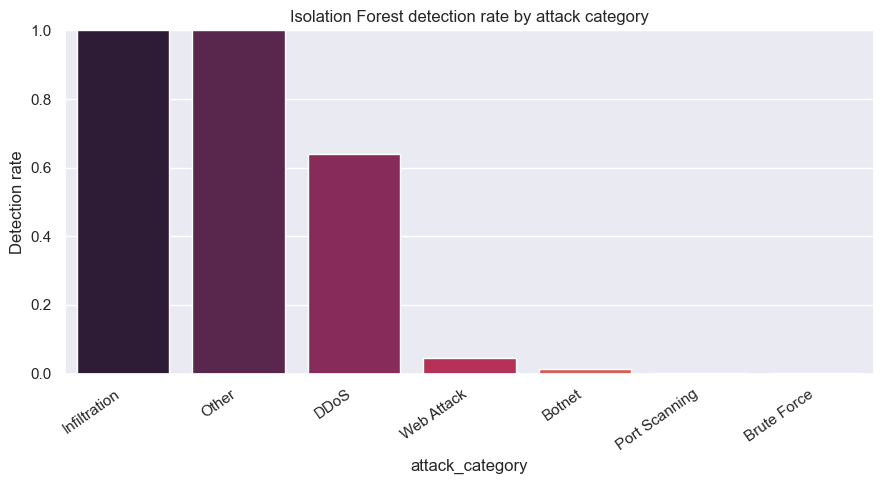

In [10]:
eval_df = df.loc[X_test.index, ["attack_category"]].copy()
eval_df["is_anomaly"] = pred["is_anomaly"].values

recall_by_category = (
    eval_df[eval_df["attack_category"] != "Normal"]
    .groupby("attack_category")["is_anomaly"]
    .mean()
    .sort_values(ascending=False)
)
print("Detection rate (recall) by attack category:")
print(recall_by_category)

plt.figure(figsize=(9, 5))
sns.barplot(x=recall_by_category.index, y=recall_by_category.values, hue=recall_by_category.index, palette="rocket", legend=False)
plt.xticks(rotation=35, ha="right")
plt.ylabel("Detection rate")
plt.ylim(0, 1)
plt.title("Isolation Forest detection rate by attack category")
plt.tight_layout()
plt.show()

## 6. Save the trained model

Saved with `joblib`, the standard format for scikit-learn models. This is the same file the FastAPI `/detect` endpoint will load in a later phase — trained once here, reused everywhere, so what we evaluate in this notebook is exactly what would run in production.


In [11]:
save_model(model, MODELS_DIR / "isolation_forest_v1.joblib")

Model saved -> c:\Users\Microsoft\Desktop\Nayi_Manzil_Internship\ThreatLensAI\models\anomaly\isolation_forest_v1.joblib


## 7. Summary & next steps

| Item | Result |
|---|---|
| Model | Isolation Forest, 200 trees |
| Features used | see Section 2 output above |
| Precision / Recall / F1 | see Section 5 output above |
| Best-detected attack types | see Section 5 bar chart |
| Weakest-detected attack types | see Section 5 bar chart |
| Saved model | `models/anomaly/isolation_forest_v1.joblib` |

**Honest limitation:** Isolation Forest tells us *something is wrong*, not *what* is wrong — and Section 5's breakdown shows it won't catch every attack type equally well (attacks that look statistically similar to normal traffic in these features are naturally harder for a purely unsupervised method). That's expected, not a bug.

**Next notebook (`03_attack_classifier.ipynb`)** addresses that gap directly: a supervised multi-class classifier (Random Forest → XGBoost comparison) that uses the real attack labels to say specifically *which* attack type a row is, with per-class precision/recall/F1 and a full confusion matrix.
